c:\Users\USER\Desktop\Python-Project\Python-Project\MS_project03_DL\ch02
c:\Users\USER\Desktop\Python-Project\Python-Project\MS_project03_DL
7
(784,)
(28, 28)


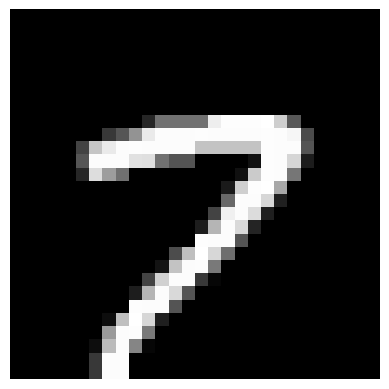

In [1]:
# coding: utf-8
import sys, os
print(os.getcwd())
current_dir = os.path.dirname(os.getcwd())
parent_dir = os.path.dirname(current_dir)
print(current_dir)
sys.path.append(current_dir)

import numpy as np
from dataset.mnist import load_mnist
from PIL import Image
import matplotlib.pyplot as plt

def img_show(img):
    plt.imshow(img, cmap='gray')
    plt.axis('off') # 축 숨기기
    plt.show()

(x_train, t_train), (x_test, t_test) = load_mnist(flatten=True, normalize=False)

img = x_train[123]
label = t_train[123]
print(label)

print(img.shape) # (784,)
img = img.reshape(28, 28) # 1차원 이미지를 2차원 이미지로 변경
print(img.shape) # (28, 28)

img_show(img)


In [ ]:
import os, sys, time
print(os.getcwd())
current_dir = os.path.dirname(os.getcwd())
parent_dir = os.path.dirname(current_dir)
print(current_dir)
os.chdir(current_dir)

import numpy as np
import pickle
from dataset.mnist import load_mnist
from common.functions import sigmoid, softmax

def get_data():
    (x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, flatten=True, one_hot_label=False)
    return x_test, t_test

def init_network():
    print(os.getcwd())
    with open("C:/Users/USER/Desktop/Python-Project/Python-Project/MS_project03_DL/ch02/sample_weight.pkl", 'rb') as f:
        network = pickle.load(f)
    return network

def predict(network, x):
    W1, W2, W3 = network['W1'], network['W2'], network['W3']
    b1, b2, b3 = network['b1'], network['b2'], network['b3']

    a1 = np.dot(x, W1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, W2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, W3) + b3
    y = softmax(a3)
    return y

x, t = get_data()
network = init_network()
accuracy_cnt = 0
wrong_cnt = np.zeros(10, dtype=int)

for i in range(len(x)):
    y = predict(network, x[i])
    p = np.argmax(y)
    if p == t[i]:
        print(f'Predicted num: {p}, Original num: {t[i]}')
        accuracy_cnt += 1
    else:
        wrong_cnt[t[i]] += 1  # 정답(label) 숫자 인덱스에 +1
        # time.sleep(0.5)

print("Accuracy:" + str(float(accuracy_cnt) / len(x)))
print("숫자별 오답수:", wrong_cnt)  


c:\Users\USER\Desktop
c:\Users\USER
c:\Users\USER
Accuracy:1.0
